# MAYA_DC RD Curves and Fixed-Patch Reconstructions

This notebook is tailored to the `cedric-leonard/MAYA_DC` WandB project.
It does two things:

1. fetches runs from WandB, caches the large run table to CSV, filters MAYA_DC runs, aggregates seed statistics, and plots reusable RD curves;
2. loads one or more trained checkpoints from `run_output_dir/checkpoints/last.ckpt`, runs fixed-patch inference in-notebook, and displays `RCMC`, `RCMC_recon`, `SLC`, and `SLC_recon`.

The plotting/filtering helpers intentionally keep a few future-facing knobs around so the notebook still works if we later introduce new activations, training modes, or architectures.


## Imports and project setup


In [1]:
from __future__ import annotations

import json
import re
import sys
from pathlib import Path
from typing import Any

import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb
from IPython.display import display
from omegaconf import DictConfig, OmegaConf


def find_project_root(start: Path, marker: str = '.project-root') -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / marker).exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Could not find project root from {start} using marker '{marker}'.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Cache lives alongside the imported cluster results, not under notebooks/
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks'
CACHE_DIR = NOTEBOOK_DIR / 'paper_results'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'CACHE_DIR:    {CACHE_DIR}')
print(f'DEVICE:       {DEVICE}')


PROJECT_ROOT: /mnt/vitisAI/Vitis-AI/MAYA_DC
CACHE_DIR:    /mnt/vitisAI/Vitis-AI/MAYA_DC/data/from_cluster/cache
DEVICE:       cuda


## WandB cache configuration


In [2]:
WANDB_ENTITY = 'cedric-leonard'
WANDB_PROJECT = 'MAYA_DC'

RUNS_CACHE_CSV = CACHE_DIR / f'wandb_runs_{WANDB_ENTITY}_{WANDB_PROJECT}.csv'
RD_STATS_CSV = CACHE_DIR / f'rd_stats_{WANDB_ENTITY}_{WANDB_PROJECT}.csv'
RD_STATS_WITH_BASELINES_CSV = CACHE_DIR / f'rd_stats_with_baselines_{WANDB_ENTITY}_{WANDB_PROJECT}.csv'
DEFAULT_BASELINE_SUMMARY_CSVS = [
    CACHE_DIR / 'jpeg_baseline_rcmc_channels_slc_summary.csv',
    CACHE_DIR / 'webp_baseline_rcmc_channels_slc_summary.csv',
    CACHE_DIR / 'jpeg2000_baseline_rcmc_channels_slc_summary.csv',
]

# Set True only when you want to pull fresh data from WandB (requires network + login).
# The CSV in CACHE_DIR was imported from the cluster and is used by default.
FORCE_REFRESH_RUN_CACHE = False
WANDB_API_TIMEOUT = 180
VERBOSE_FETCH = True

RUNS_CACHE_CSV


PosixPath('/mnt/vitisAI/Vitis-AI/MAYA_DC/data/from_cluster/cache/wandb_runs_cedric-leonard_MAYA_DC.csv')

In [3]:
MODEL_SHORT_NAMES = {
    'ScaleHyperprior': 'SH',
    'FactorizedPrior': 'FP',
}

DATASET_SHORT_NAMES = {
    'MAYA4DataModule': 'MAYA4',    # actual class name from _target_
    'MAYA4DirDataModule': 'MAYA4', # actual class name from _target_
    'Maya4DataModule': 'MAYA4',    # legacy / alternate casing
    'Maya4DirDataModule': 'MAYA4', # legacy / alternate casing
}

ACTIVATION_SHORT_NAMES = {
    'gdn': 'GDN',
    'relu': 'ReLU',
}

LOSS_SHORT_NAMES = {
    'CompoundCompressionLoss': 'Compound',
    'SimpleMSELoss': 'MSE',
}

METRIC_ALIASES = {
    'rate': ['test/rate', 'test/rate_epoch', 'test/bpp', 'test/bpp_epoch'],
    'psnr_amp': [
        'test/psnr_amp',
        'test/psnr_amp_epoch',
        'test/psnr_noisy',
        'test/psnr_noisy_epoch',
        'test/psnr_merlin',
        'test/psnr_merlin_epoch',
        'test/psnr_adam_noc',
        'test/psnr_adam_noc_epoch',
    ],
    'ssim_amp': [
        'test/ssim_amp',
        'test/ssim_amp_epoch',
        'test/ssim_noisy',
        'test/ssim_noisy_epoch',
        'test/ssim_merlin',
        'test/ssim_merlin_epoch',
        'test/ssim_adam_noc',
        'test/ssim_adam_noc_epoch',
    ],
    'complex_corr': [
        'test/complex_corr_mean',
        'test/complex_corr_mean_epoch',
        'test/coherence',
        'test/coherence_mean',
    ],
    'phase_err': ['test/phase_err_mean', 'test/phase_err_mean_epoch'],
}

PRETTY_METRIC_NAMES = {
    'test/rate': 'Bit-rate [bpp]',
    'test/rate_epoch': 'Bit-rate [bpp]',
    'test/bpp': 'Bit-rate [bpp]',
    'test/bpp_epoch': 'Bit-rate [bpp]',
    'test/psnr_amp': 'PSNR [dB]',
    'test/psnr_amp_epoch': 'PSNR [dB]',
    'test/psnr_noisy': 'PSNR [dB]',
    'test/ssim_amp': 'SSIM',
    'test/ssim_amp_epoch': 'SSIM',
    'test/complex_corr_mean': 'Complex correlation',
    'test/complex_corr_mean_epoch': 'Complex correlation',
    'test/phase_err_mean': 'Phase error',
    'test/phase_err_mean_epoch': 'Phase error',
}


def _dict_select(mapping: Any, key: str, default: Any = None) -> Any:
    if isinstance(mapping, dict) and key in mapping:
        return mapping.get(key, default)
    if isinstance(mapping, dict):
        alt_key = key.replace('.', '/')
        if alt_key in mapping:
            return mapping.get(alt_key, default)
    cursor = mapping
    for part in key.split('.'):
        if isinstance(cursor, dict) and part in cursor:
            cursor = cursor[part]
        else:
            return default
    return cursor


def _cfg_select(cfg: DictConfig, key: str, default: Any = None) -> Any:
    try:
        value = OmegaConf.select(cfg, key, default=default)
        return default if value is None else value
    except Exception:
        pass
    try:
        container = OmegaConf.to_container(cfg, resolve=False)
    except Exception:
        return default
    value = _dict_select(container, key, default)
    return default if value is None else value


def _json_dumps(value: Any) -> str:
    return json.dumps(value, default=str, sort_keys=True)


def _json_loads(value: Any, default: Any) -> Any:
    if isinstance(value, (dict, list)):
        return value
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return default
    if isinstance(value, str) and not value.strip():
        return default
    return json.loads(value)


def shorten_model_name(model_target: str | None) -> str:
    if not model_target:
        return 'UnknownModel'
    last = str(model_target).split('.')[-1]
    return MODEL_SHORT_NAMES.get(last, last)


def shorten_dataset_name(data_target: str | None) -> str:
    if not data_target:
        return 'UnknownDataset'
    last = str(data_target).split('.')[-1]
    return DATASET_SHORT_NAMES.get(last, last)


def shorten_activation_name(activation: str | None) -> str:
    if not activation:
        return 'UnknownAct'
    return ACTIVATION_SHORT_NAMES.get(str(activation).lower(), str(activation))


def shorten_loss_name(loss_target: str | None) -> str:
    if not loss_target:
        return 'UnknownLoss'
    last = str(loss_target).split('.')[-1]
    return LOSS_SHORT_NAMES.get(last, last)


def parse_run_name_metadata(run_name: str | None) -> dict[str, Any]:
    if not isinstance(run_name, str):
        return {}

    pattern = re.compile(
        r'^(?P<model_short>[^-_]+)-(?P<activation>[^_]+)'
        r'_s(?P<seed>[^_]+)'
        r'_L(?P<lmbda>[^_]+)'
        r'_(?P<training_mode>[^_]+)'
        r'_buf(?P<azimuth_buffer>[^_]+)'
        r'_(?P<criterion_short>[^_]+)'
        r'(?:_lr(?P<lr>[^_]+))?'
        r'(?:_b(?P<batch_size>[^_]+))?'
        r'(?:_(?P<patches_seen>\d+)p)?$'
    )
    match = pattern.match(run_name.strip())
    if match is None:
        return {}

    info = match.groupdict()
    model_short = info.get('model_short')
    activation = info.get('activation')
    criterion_short = info.get('criterion_short')

    return {
        'model_short': model_short,
        'model_name': {
            'SH': 'ScaleHyperprior', 'SHyp': 'ScaleHyperprior', 'SHP': 'ScaleHyperprior',
            'FP': 'FactorizedPrior',
        }.get(model_short, model_short),
        'activation': activation,
        'activation_short': shorten_activation_name(activation),
        'seed': pd.to_numeric(info.get('seed'), errors='coerce'),
        'lmbda': pd.to_numeric(info.get('lmbda'), errors='coerce'),
        'training_mode': info.get('training_mode'),
        'azimuth_buffer': pd.to_numeric(info.get('azimuth_buffer'), errors='coerce'),
        'criterion_short': criterion_short,
        'criterion_target': criterion_short,
        'lr': pd.to_numeric(info.get('lr'), errors='coerce'),
        'batch_size': pd.to_numeric(info.get('batch_size'), errors='coerce'),
        'patches_seen': pd.to_numeric(info.get('patches_seen'), errors='coerce'),
    }


def infer_dataset_short(tags: list[str] | None, project: str | None = None) -> str:
    lowered_tags = {str(tag).lower() for tag in (tags or [])}
    if 'maya4' in lowered_tags or str(project) == 'MAYA_DC':
        return 'MAYA4'
    return 'UnknownDataset'


def fill_missing_scalar(current: Any, fallback: Any, unknown_tokens: set[str] | None = None) -> Any:
    unknown_tokens = unknown_tokens or set()
    if current is None:
        return fallback
    if isinstance(current, float) and pd.isna(current):
        return fallback
    if isinstance(current, str) and (not current.strip() or current in unknown_tokens):
        return fallback
    return current


def repair_run_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    repaired = df.copy()
    for column in [
        'training_mode',
        'model_short',
        'model_name',
        'activation',
        'activation_short',
        'criterion_short',
        'criterion_target',
        'dataset_short',
        'group_label',
        'non_square_kernels',
    ]:
        if column not in repaired.columns:
            repaired[column] = None
        repaired[column] = repaired[column].astype(object)
    parsed_rows = repaired['run_name'].apply(parse_run_name_metadata)

    for idx, parsed in parsed_rows.items():
        if not parsed:
            continue
        for column in ['seed', 'lmbda', 'training_mode', 'azimuth_buffer']:
            repaired.at[idx, column] = fill_missing_scalar(repaired.at[idx, column], parsed.get(column))
        for column in ['model_short', 'model_name', 'activation', 'activation_short', 'criterion_short', 'criterion_target']:
            repaired.at[idx, column] = fill_missing_scalar(
                repaired.at[idx, column],
                parsed.get(column),
                unknown_tokens={'UnknownModel', 'UnknownAct', 'UnknownLoss'},
            )

    repaired['dataset_short'] = [
        fill_missing_scalar(current, infer_dataset_short(tags, project), {'UnknownDataset'})
        for current, tags, project in zip(
            repaired.get('dataset_short', pd.Series(index=repaired.index, dtype=object)),
            repaired['tags'],
            repaired['project'],
        )
    ]
    # Normalize any stale class-name-style values loaded from cached CSVs
    # (e.g., 'MAYA4DirDataModule' stored when the mapping missed the uppercase key).
    repaired['dataset_short'] = repaired['dataset_short'].map(
        lambda x: DATASET_SHORT_NAMES.get(str(x), x) if pd.notna(x) else x
    )
    repaired['seed'] = pd.to_numeric(repaired['seed'], errors='coerce')
    repaired['lmbda'] = pd.to_numeric(repaired['lmbda'], errors='coerce')
    repaired['azimuth_buffer'] = pd.to_numeric(repaired['azimuth_buffer'], errors='coerce')
    # Normalize legacy / run-name-style model tokens to canonical display names.
    # Covers 'SHyp' and 'SHP' -> 'SH' when the WandB config _target_ was absent
    # and the token was parsed directly from the run name.
    _MODEL_SHORT_ALIASES = {'SHyp': 'SH', 'SHP': 'SH'}
    repaired['model_short'] = repaired['model_short'].map(
        lambda x: _MODEL_SHORT_ALIASES.get(str(x), x) if pd.notna(x) else x
    )
    repaired['group_label'] = repaired.apply(build_group_label, axis=1)
    return repaired



def build_group_label(row_like: dict[str, Any] | pd.Series) -> str:
    model_short = row_like.get('model_short', 'UnknownModel')
    activation_short = row_like.get('activation_short', 'UnknownAct')
    dataset_short = row_like.get('dataset_short', 'UnknownDataset')
    training_mode = row_like.get('training_mode', 'unknown_mode')
    parts = [
        f"{model_short}-{activation_short}",
        str(dataset_short),
        str(training_mode),
    ]
    no_output_padding = row_like.get('no_output_padding')
    if pd.notna(no_output_padding):
        parts.append('no_out_pad' if bool(no_output_padding) else 'out_pad')
    non_square_kernels = row_like.get('non_square_kernels')
    if pd.notna(non_square_kernels):
        parts.append('nsk' if bool(non_square_kernels) else 'sq')
    return ' | '.join(parts)

def simplify_group_label(group_label: str) -> str:
    # traditional codecs
    if '(' in group_label:
        return group_label.split('(')[0].strip()
    # models
    parts = group_label.split('|')
    model_name = parts[0].split('-')[0].strip()
    nsk = parts[-1].strip()
    if nsk == "sq":
        return model_name
    return f"{model_name} - {nsk.upper()}"

def extract_run_record(run: Any) -> dict[str, Any]:
    cfg = OmegaConf.create(run.config)
    summary = dict(run.summary._json_dict)
    tags = sorted(
        {
            str(tag)
            for tag in list(getattr(run, 'tags', []) or []) + list(_cfg_select(cfg, 'tags', []) or [])
        }
    )
    activation = _cfg_select(cfg, 'model.net.activation', None)
    model_target = _cfg_select(cfg, 'model.net._target_', '')
    data_target = _cfg_select(cfg, 'data._target_', '')
    loss_target = _cfg_select(cfg, 'model.criterion._target_', '')
    activation = _cfg_select(cfg, 'model.net.activation', None)
    no_output_padding = _cfg_select(cfg, 'model.net.no_output_padding', None)

    wandb_group = getattr(run, 'group', None) or _cfg_select(cfg, 'logger.wandb.group', None)
    non_square_kernels = _cfg_select(cfg, 'model.net.non_square_kernels', None)
    if non_square_kernels is None:
        group_hint = str(wandb_group or '').lower()
        tag_hints = {str(tag).lower() for tag in tags}
        if 'non_square' in group_hint or 'nsk' in group_hint or 'non_square' in tag_hints or 'nsk' in tag_hints:
            non_square_kernels = True
    if non_square_kernels is None:
        non_square_kernels = False

    record = {
        'id': run.id,
        'run_name': run.name,
        'state': getattr(run, 'state', None),
        'url': getattr(run, 'url', None),
        'created_at': getattr(run, 'created_at', None),
        'entity': WANDB_ENTITY,
        'project': WANDB_PROJECT,
        'seed': _cfg_select(cfg, 'seed', None),
        'lmbda': _cfg_select(cfg, 'model.criterion.lmbda', _cfg_select(cfg, 'lambda', None)),
        'training_mode': _cfg_select(cfg, 'model.training_mode', None),
        'azimuth_buffer': _cfg_select(cfg, 'azimuth_buffer', _cfg_select(cfg, 'model.azimuth_buffer', None)),
        'model_target': model_target,
        'model_name': str(model_target).split('.')[-1] if model_target else None,
        'model_short': shorten_model_name(model_target),
        'activation': activation,
        'activation_short': shorten_activation_name(activation),
        'data_target': data_target,
        'data_name': str(data_target).split('.')[-1] if data_target else None,
        'dataset_short': shorten_dataset_name(data_target),
        'criterion_target': loss_target,
        'criterion_short': shorten_loss_name(loss_target),
        'run_output_dir': _cfg_select(cfg, 'paths.output_dir', None),
        'no_output_padding': no_output_padding,
        'non_square_kernels': non_square_kernels,
        'wandb_group': wandb_group,
        'tags': tags,
        'group_label': None,  # filled below once all fields are present
        'summary': summary,
        'config': OmegaConf.to_container(cfg, resolve=False),
    }
    record['group_label'] = build_group_label(record)
    return record


def save_runs_cache(df: pd.DataFrame, cache_csv: Path) -> None:
    serializable = df.copy()
    for column in ['summary', 'config', 'tags']:
        serializable[column] = serializable[column].apply(_json_dumps)
    serializable.to_csv(cache_csv, index=False)
    print(f'Saved {len(serializable)} runs to {cache_csv}')


def load_runs_cache(cache_csv: Path) -> pd.DataFrame:
    cached = pd.read_csv(cache_csv)
    for column, default in [('summary', {}), ('config', {}), ('tags', [])]:
        cached[column] = cached[column].apply(lambda value: _json_loads(value, default))
    return repair_run_dataframe(cached)


def fetch_runs_dataframe(
    entity: str,
    project: str,
    cache_csv: Path,
    force_refresh: bool = False,
    timeout: int = 60,
    verbose: bool = True,
) -> pd.DataFrame:
    if cache_csv.exists() and not force_refresh:
        print(f'Loading cached runs from {cache_csv}')
        return load_runs_cache(cache_csv)

    api = wandb.Api(timeout=timeout)
    runs = api.runs(f'{entity}/{project}')
    records = []
    for run in runs:
        if not getattr(run, 'config', None):
            run = api.run(f'{entity}/{project}/{run.id}')
        records.append(extract_run_record(run))
    df = pd.DataFrame.from_records(records)
    df = repair_run_dataframe(df)
    df.sort_values(['model_short', 'activation_short', 'training_mode', 'lmbda', 'seed'], inplace=True)
    save_runs_cache(df, cache_csv)
    if verbose:
        print(f'Fetched {len(df)} runs from {entity}/{project}')
    return df.reset_index(drop=True)


def collect_summary_keys(df: pd.DataFrame) -> list[str]:
    keys: set[str] = set()
    for summary in df['summary']:
        keys.update(summary.keys())
    return sorted(keys)


def metric_candidates(metric_name: str) -> list[str]:
    return METRIC_ALIASES.get(metric_name, [metric_name])


In [4]:
def filter_baseline_by_bpp(df: pd.DataFrame, max_bpp: float | None) -> pd.DataFrame:
    """Drop baseline rows where rate_mean exceeds max_bpp. Pass max_bpp=None to disable."""
    if df.empty or max_bpp is None:
        return df
    rate_col = next((c for c in ('rate_mean', 'bpp_mean', 'bpp') if c in df.columns), None)
    if rate_col is None:
        return df
    return df.loc[df[rate_col] <= max_bpp].copy()


In [5]:
runs_df = fetch_runs_dataframe(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    cache_csv=RUNS_CACHE_CSV,
    force_refresh=FORCE_REFRESH_RUN_CACHE,
    timeout=WANDB_API_TIMEOUT,
    verbose=VERBOSE_FETCH,
)

print(f'Loaded {len(runs_df)} runs.')
display(
    runs_df[
        [
            'id',
            'run_name',
            'model_short',
            'activation_short',
            'dataset_short',
            'training_mode',
            'criterion_short',
            'lmbda',
            'seed',
            'state',
        ]
    ].head()
)


Loading cached runs from /mnt/vitisAI/Vitis-AI/MAYA_DC/data/from_cluster/cache/wandb_runs_cedric-leonard_MAYA_DC.csv
Loaded 101 runs.


,id,run_name,model_short,activation_short,dataset_short,training_mode,criterion_short,lmbda,seed,state
0,bj4n6to3,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b4,SH,GDN,MAYA4,rcmc,MSE,100.0,42.0,finished
1,ca5ri2wt,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b4_10000p,SH,GDN,MAYA4,rcmc,MSE,100.0,42.0,finished
2,t8mbsbrs,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b8_10000p,SH,GDN,MAYA4,rcmc,MSE,100.0,42.0,finished
3,xv3wp3k4,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b4_10000p,SH,GDN,MAYA4,rcmc,MSE,100.0,42.0,finished
4,nb5k66eb,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b4_10000p,SH,GDN,MAYA4,rcmc,MSE,100.0,42.0,finished


## Filtering and experiment overview


In [6]:
FILTER_CFG = {
    'seed_min': 0,
    'seed_max': 10,
    'blocked_tags': ['debug', 'crashed', 'BART'],
    # 'accepted_training_modes': ['slc'],
    # 'accepted_dataset_shorts': ['MAYA4'],
    # 'accepted_activation_shorts': ['GDN'],
    # 'accepted_model_shorts': ['SH'],
    # 'accepted_lambdas': [5, 7, 10, 20, 50, 100, 1000],
    # 'include_run_name_substrings': ['buf512'],
    # 'exclude_run_name_substrings': ['prototype'],
}


def print_removed_runs(title: str, removed_df: pd.DataFrame) -> None:
    if removed_df.empty:
        print(f'{title}: 0')
        return
    print(f'{title}: {len(removed_df)}')
    display(
        removed_df[
            [
                'id',
                'run_name',
                'seed',
                'lmbda',
                'model_short',
                'activation_short',
                'dataset_short',
                'training_mode',
                'tags',
            ]
        ]
    )


def apply_run_filters(df: pd.DataFrame, cfg: dict[str, Any], verbose: bool = True) -> pd.DataFrame:
    work = df.copy()
    work['seed'] = pd.to_numeric(work['seed'], errors='coerce')
    work['lmbda'] = pd.to_numeric(work['lmbda'], errors='coerce')

    seed_mask = work['seed'].between(cfg['seed_min'], cfg['seed_max'], inclusive='both')
    removed_seed = work.loc[~seed_mask].copy()
    work = work.loc[seed_mask].copy()
    if verbose:
        print_removed_runs(
            f"Removed runs outside seed range [{cfg['seed_min']}, {cfg['seed_max']}]",
            removed_seed,
        )

    blocked = [tag.lower() for tag in cfg.get('blocked_tags', [])]
    blocked_mask = work['tags'].apply(
        lambda tags: any(blocked_tag in str(tag).lower() for tag in (tags or []) for blocked_tag in blocked)
    )
    removed_tags = work.loc[blocked_mask].copy()
    work = work.loc[~blocked_mask].copy()
    if verbose:
        print_removed_runs('Removed runs with blocked tags', removed_tags)

    accepted_training_modes = cfg.get('accepted_training_modes')
    if accepted_training_modes is not None:
        work = work.loc[work['training_mode'].isin(accepted_training_modes)].copy()

    accepted_dataset_shorts = cfg.get('accepted_dataset_shorts')
    if accepted_dataset_shorts is not None:
        work = work.loc[work['dataset_short'].isin(accepted_dataset_shorts)].copy()

    accepted_activation_shorts = cfg.get('accepted_activation_shorts')
    if accepted_activation_shorts is not None:
        work = work.loc[work['activation_short'].isin(accepted_activation_shorts)].copy()

    accepted_model_shorts = cfg.get('accepted_model_shorts')
    if accepted_model_shorts is not None:
        work = work.loc[work['model_short'].isin(accepted_model_shorts)].copy()

    accepted_lambdas = cfg.get('accepted_lambdas')
    if accepted_lambdas is not None:
        work = work.loc[work['lmbda'].isin(accepted_lambdas)].copy()

    include_substrings = cfg.get('include_run_name_substrings')
    if include_substrings is not None:
        include_mask = work['run_name'].apply(
            lambda name: any(token.lower() in str(name).lower() for token in include_substrings)
        )
        work = work.loc[include_mask].copy()

    exclude_substrings = cfg.get('exclude_run_name_substrings')
    if exclude_substrings is not None:
        exclude_mask = work['run_name'].apply(
            lambda name: any(token.lower() in str(name).lower() for token in exclude_substrings)
        )
        work = work.loc[~exclude_mask].copy()

    work.sort_values(
        ['dataset_short', 'model_short', 'activation_short', 'training_mode', 'lmbda', 'seed'],
        inplace=True,
    )
    return work.reset_index(drop=True)


def default_group_columns(df: pd.DataFrame) -> list[str]:
    columns = ['model_short', 'activation_short', 'dataset_short', 'training_mode']
    if 'no_output_padding' in df.columns and df['no_output_padding'].nunique(dropna=True) > 1:
        columns.append('no_output_padding')
    if 'non_square_kernels' in df.columns and df['non_square_kernels'].nunique(dropna=True) > 1:
        columns.append('non_square_kernels')
    return columns


def summarize_groups(df: pd.DataFrame, group_columns: list[str]) -> pd.DataFrame:
    summary = (
        df.groupby(group_columns, dropna=False)
        .agg(
            num_runs=('id', 'size'),
            num_lambdas=('lmbda', 'nunique'),
            num_seeds=('seed', 'nunique'),
            min_lambda=('lmbda', 'min'),
            max_lambda=('lmbda', 'max'),
            min_seed=('seed', 'min'),
            max_seed=('seed', 'max'),
        )
        .reset_index()
        .sort_values(group_columns)
    )
    return summary


filtered_runs_df = apply_run_filters(runs_df, FILTER_CFG, verbose=True)
GROUP_COLUMNS = default_group_columns(filtered_runs_df)

print(f'Kept {len(filtered_runs_df)} runs after filtering.')
display(
    summarize_groups(filtered_runs_df, GROUP_COLUMNS)
)

available_test_metrics = [key for key in collect_summary_keys(filtered_runs_df) if key.startswith('test/')]
print('Available test metrics:')
print(available_test_metrics)


Removed runs outside seed range [0, 10]: 29


,id,run_name,seed,lmbda,model_short,activation_short,dataset_short,training_mode,tags
0,bj4n6to3,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b4,42.0,100.00,SH,GDN,MAYA4,rcmc,"[ , ', ,, 4, BART, [, ], _, a, c, e, h, i, l, m, maya4, n, o, p, r, rcmc_compression, s, scale_hyperprior, y]"
1,ca5ri2wt,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b4_10000p,42.0,100.00,SH,GDN,MAYA4,rcmc,"[ , ', ,, 4, [, ], _, a, c, e, h, i, l, m, maya4, n, o, p, r, rcmc_compression, s, scale_hyperprior, y]"
2,t8mbsbrs,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b8_10000p,42.0,100.00,SH,GDN,MAYA4,rcmc,"[maya4, rcmc_compression, scale_hyperprior]"
3,xv3wp3k4,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b4_10000p,42.0,100.00,SH,GDN,MAYA4,rcmc,"[ , ', ,, 4, [, ], _, a, c, e, h, i, l, m, maya4, n, o, p, r, rcmc_compression, s, scale_hyperprior, y]"
4,nb5k66eb,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b4_10000p,42.0,100.00,SH,GDN,MAYA4,rcmc,"[ , ', ,, 4, [, ], _, a, c, e, h, i, l, m, maya4, n, o, p, r, rcmc_compression, s, scale_hyperprior, y]"
5,j0rt3sgg,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b4_10000p,42.0,100.00,SH,GDN,MAYA4,rcmc,"[ , ', ,, 4, [, ], _, a, c, e, h, i, l, m, maya4, n, o, p, r, rcmc_compression, s, scale_hyperprior, y]"
6,10jiwfni,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b4_10000p,42.0,100.00,SH,GDN,MAYA4,rcmc,"[ , ', ,, 4, [, ], _, a, c, e, h, i, l, m, maya4, n, o, p, r, rcmc_compression, s, scale_hyperprior, y]"
7,hkarq0ic,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b4_10000p,42.0,100.00,SH,GDN,MAYA4,rcmc,"[ , ', ,, 4, [, ], _, a, c, e, h, i, l, m, maya4, n, o, p, r, rcmc_compression, s, scale_hyperprior, y]"
8,w2voe8hj,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b4_10000p,42.0,100.00,SH,GDN,MAYA4,rcmc,"[ , ', ,, 4, [, ], _, a, c, e, h, i, l, m, maya4, n, o, p, r, rcmc_compression, s, scale_hyperprior, y]"
9,r0oxu6h9,SHP-gdn_s42_L100.0_rcmc_buf512_MSE_lr0.0001_b12_10000p,42.0,100.00,SH,GDN,MAYA4,rcmc,"[maya4, rcmc_compression, scale_hyperprior]"


Removed runs with blocked tags: 0
Kept 72 runs after filtering.


,model_short,activation_short,dataset_short,training_mode,non_square_kernels,num_runs,num_lambdas,num_seeds,min_lambda,max_lambda,min_seed,max_seed
0,SH,GDN,MAYA4,slc,False,36,12,3,1.0,1000.0,0.0,2.0
1,SH,GDN,MAYA4,slc,True,36,12,3,1.0,1000.0,0.0,2.0


Available test metrics:
['test/aux', 'test/coherence', 'test/complex_corr_mean', 'test/complex_corr_std', 'test/distortion', 'test/kde', 'test/loss', 'test/mse', 'test/phase_err_mean', 'test/phase_err_std', 'test/psnr_amp', 'test/rate', 'test/ssim_amp']


## RD aggregation and plotting


In [7]:
def resolve_metric_key(df: pd.DataFrame, metric_name: str) -> str:
    available_keys = set(collect_summary_keys(df))
    for candidate in metric_candidates(metric_name):
        if candidate in available_keys:
            return candidate
    raise KeyError(
        f"Could not resolve metric '{metric_name}'. Candidates: {metric_candidates(metric_name)}. "
        f"Available test metrics: {[key for key in sorted(available_keys) if key.startswith('test/')] }"
    )


def extract_metric_values(df: pd.DataFrame, metric_key: str) -> pd.Series:
    if metric_key in df.columns:
        return pd.to_numeric(df[metric_key], errors='coerce')
    return pd.to_numeric(df['summary'].apply(lambda summary: summary.get(metric_key)), errors='coerce')


def aggregate_rd_statistics(
    df: pd.DataFrame,
    rate_metric: str = 'rate',
    quality_metric: str = 'psnr_amp',
    group_columns: list[str] | None = None,
) -> tuple[pd.DataFrame, dict[str, str]]:
    group_columns = group_columns or default_group_columns(df)
    resolved_rate_metric = resolve_metric_key(df, rate_metric)
    resolved_quality_metric = resolve_metric_key(df, quality_metric)

    records: list[dict[str, Any]] = []
    for group_values, group_df in df.groupby(group_columns, dropna=False):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)
        group_meta = dict(zip(group_columns, group_values))
        group_meta['group_label'] = build_group_label(group_meta)

        for lmbda, lambda_df in group_df.groupby('lmbda', dropna=False):
            rate_values = extract_metric_values(lambda_df, resolved_rate_metric).dropna()
            quality_values = extract_metric_values(lambda_df, resolved_quality_metric).dropna()
            if rate_values.empty or quality_values.empty:
                continue

            record = {
                **group_meta,
                'lmbda': lmbda,
                'num_runs': len(lambda_df),
                'num_seed_values': lambda_df['seed'].nunique(dropna=True),
                'rate_mean': rate_values.mean(),
                'rate_std': rate_values.std(ddof=0),
                'rate_min': rate_values.min(),
                'rate_max': rate_values.max(),
                'quality_mean': quality_values.mean(),
                'quality_std': quality_values.std(ddof=0),
                'quality_min': quality_values.min(),
                'quality_max': quality_values.max(),
            }
            records.append(record)

    stats_df = pd.DataFrame.from_records(records)
    if stats_df.empty:
        raise ValueError('No statistics could be computed for the requested plot metrics after filtering.')

    stats_df.sort_values(group_columns + ['lmbda'], inplace=True)
    return stats_df.reset_index(drop=True), {
        'rate_metric': resolved_rate_metric,
        'quality_metric': resolved_quality_metric,
    }


def pretty_metric_name(metric_key: str) -> str:
    return PRETTY_METRIC_NAMES.get(metric_key, metric_key)


def format_lambda(value: float) -> str:
    if pd.isna(value):
        return 'nan'
    rounded = round(float(value))
    return str(int(rounded)) if abs(float(value) - rounded) < 1e-9 else f'{float(value):g}'


def build_single_group_title(stats_df: pd.DataFrame) -> str:
    row = stats_df.iloc[0]
    title_parts = [f"{row['model_short']}-{row['activation_short']}", row['dataset_short'], str(row['training_mode'])]
    if 'no_output_padding' in stats_df.columns and pd.notna(row.get('no_output_padding')):
        title_parts.append('no_out_pad' if bool(row['no_output_padding']) else 'out_pad')
    if 'non_square_kernels' in stats_df.columns and pd.notna(row.get('non_square_kernels')):
        title_parts.append('nsk' if bool(row['non_square_kernels']) else 'sq')
    return ' | '.join(title_parts)


def plot_rd_curve(
    stats_df: pd.DataFrame,
    resolved_rate_metric: str,
    resolved_quality_metric: str,
    show_rate_error_bars: bool = True,
    show_quality_error_bars: bool = False,
    show_quality_band: bool = True,
    annotate_lambda: bool = True,
    title: str | None = None,
    show_legend: bool | None = None,
    show_rate_error_bars_for_codecs: bool | None = None,
    ax: plt.Axes | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    """Plot an RD curve.

    show_rate_error_bars_for_codecs: when not None, overrides show_rate_error_bars
        for rows where curve_source == 'classical_codec'. Set False to hide bpp
        errorbars for traditional codecs while keeping them for model runs.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 6))
    else:
        fig = ax.figure

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    activation_linestyles = {
        'GDN': '-',
        'ReLU': '--',
    }
    training_mode_markers = {
        'slc': 'o',
        'rcmc': 's',
    }

    unique_groups = stats_df['group_label'].nunique()
    if show_legend is None:
        show_legend = unique_groups > 1
    if title is None and unique_groups == 1:
        title = build_single_group_title(stats_df)

    nb_curves = 0
    for color_idx, (group_label, group_df) in enumerate(stats_df.groupby('group_label', sort=False)):
        group_df = group_df.sort_values('rate_mean')
        row0 = group_df.iloc[0]
        # Use .get() so baseline rows missing these columns still get sensible defaults.
        linestyle = activation_linestyles.get(row0.get('activation_short', ''), '-')
        marker = training_mode_markers.get(str(row0.get('training_mode', '')), 'o')
        color = colors[color_idx % len(colors)]

        ax.plot(
            group_df['rate_mean'],
            group_df['quality_mean'],
            marker=marker,
            linestyle=linestyle,
            color=color,
            linewidth=1.8,
            markersize=6,
            label=simplify_group_label(group_label),
        )

        if show_quality_band:
            ax.fill_between(
                group_df['rate_mean'],
                group_df['quality_min'],
                group_df['quality_max'],
                color=color,
                alpha=0.15,
            )

        # Per-source error bar control: codecs can use a different setting than models.
        is_codec = str(row0.get('curve_source', '')).lower() == 'classical_codec'
        _show_rate_err = (
            show_rate_error_bars_for_codecs
            if (is_codec and show_rate_error_bars_for_codecs is not None)
            else show_rate_error_bars
        )
        if _show_rate_err or show_quality_error_bars:
            ax.errorbar(
                group_df['rate_mean'],
                group_df['quality_mean'],
                xerr=group_df['rate_std'] if _show_rate_err else None,
                yerr=group_df['quality_std'] if show_quality_error_bars else None,
                fmt='none',
                ecolor="black",
                elinewidth=1.0,
                capsize=2,
                alpha=0.9,
            )

        if annotate_lambda and nb_curves == 0 :
            for _, point in group_df.iterrows():
                ax.annotate(
                    format_lambda(point['lmbda']),
                    (point['rate_mean'], point['quality_mean']),
                    textcoords='offset points',
                    xytext=(-5, 5),
                    fontsize=9,
                    color="black",
                )
        nb_curves += 1

    if title is not None:
        ax.set_title(title)
    ax.set_xlabel(pretty_metric_name(resolved_rate_metric))
    ax.set_ylabel(pretty_metric_name(resolved_quality_metric))
    ax.grid(True, alpha=0.3)
    if show_legend:
        ax.legend(loc='best')
    plt.tight_layout()
    return fig, ax


In [8]:
RD_PLOT_CFG = {
    'rate_metric': 'rate',
    'quality_metric': 'ssim_amp',
    'group_columns': GROUP_COLUMNS,
    'show_rate_error_bars': True,
    'show_quality_error_bars': False,
    'show_quality_band': True,
    'annotate_lambda': True,
    'title': None,
    'save_stats_csv': True,
    'baseline_summary_csvs': DEFAULT_BASELINE_SUMMARY_CSVS,
    'save_combined_stats_csv': True,
    'max_codec_bpp': 4.0,  # drop baseline codec points above this bpp (None = no limit)
    # Set to True/False to override show_rate_error_bars for traditional codec curves only.
    # None means use the same value as show_rate_error_bars for all curves.
    'show_rate_error_bars_for_codecs': False,
}


Saved RD statistics to /mnt/vitisAI/Vitis-AI/MAYA_DC/data/from_cluster/cache/rd_stats_cedric-leonard_MAYA_DC.csv
Loaded baseline summary CSV: /mnt/vitisAI/Vitis-AI/MAYA_DC/data/from_cluster/cache/jpeg_baseline_rcmc_channels_slc_summary.csv
Loaded baseline summary CSV: /mnt/vitisAI/Vitis-AI/MAYA_DC/data/from_cluster/cache/webp_baseline_rcmc_channels_slc_summary.csv
Loaded baseline summary CSV: /mnt/vitisAI/Vitis-AI/MAYA_DC/data/from_cluster/cache/jpeg2000_baseline_rcmc_channels_slc_summary.csv


Saved combined RD statistics to /mnt/vitisAI/Vitis-AI/MAYA_DC/data/from_cluster/cache/rd_stats_with_baselines_cedric-leonard_MAYA_DC.csv


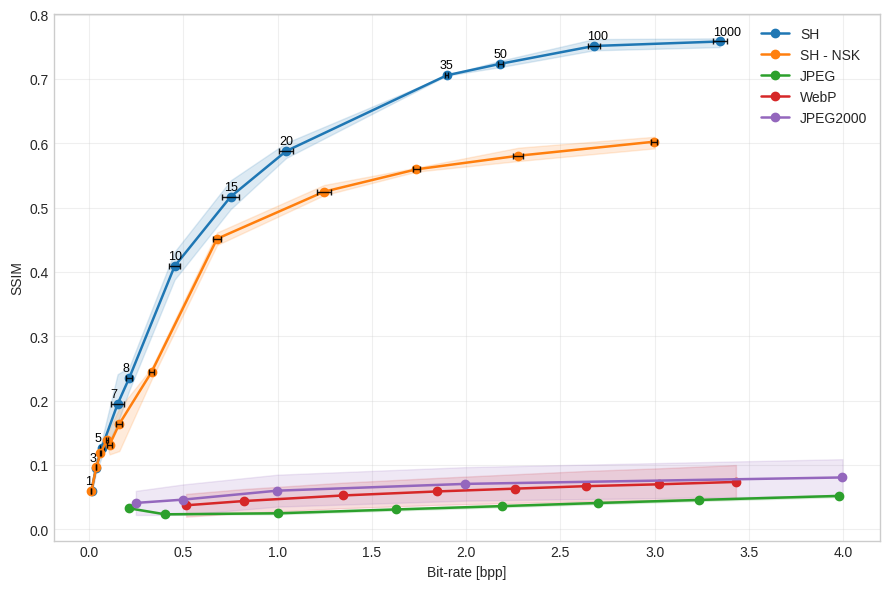

In [9]:
def load_baseline_summary_csvs(paths: list[Path]) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for path in paths:
        path = Path(path)
        if not path.exists():
            print(f'Skipping missing baseline summary CSV: {path}')
            continue
        baseline_df = pd.read_csv(path)
        if baseline_df.empty:
            print(f'Skipping empty baseline summary CSV: {path}')
            continue
        if 'curve_source' not in baseline_df.columns:
            baseline_df['curve_source'] = 'classical_codec'
        baseline_df['baseline_summary_csv'] = str(path)
        frames.append(baseline_df)
        print(f'Loaded baseline summary CSV: {path}')
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True, sort=False)


def adapt_baseline_quality(df: pd.DataFrame, resolved_quality_metric: str) -> pd.DataFrame:
    """Re-map the generic quality_mean/std/min/max columns to the requested metric.

    The evaluate_classical_codec_rd.py summary CSV contains pre-computed per-metric
    columns (psnr_amp_mean/std, ssim_amp_mean/std, complex_corr_mean_mean/std,
    phase_err_mean_mean/std). This function selects the right pair for each call
    so that plot_rd_curve always reads from quality_mean / quality_std.

    quality_std is then scaled to SEM (std / sqrt(num_runs)) so codec error bands
    represent uncertainty in the mean across patches, not patch-to-patch variability.
    Classical codecs are deterministic: their large raw std reflects diverse SAR
    scenes (ocean, urban, forest, ...) rather than any run-to-run variance.
    Dividing by sqrt(num_runs) makes the codec and model error bands directly
    comparable (both represent uncertainty in the mean).
    """
    if df.empty:
        return df
    df = df.copy()
    df['resolved_quality_metric'] = resolved_quality_metric
    df['quality_metric'] = resolved_quality_metric

    if 'ssim' in resolved_quality_metric:
        if 'ssim_amp_mean' in df.columns:
            df['quality_mean'] = df['ssim_amp_mean']
        if 'ssim_amp_std' in df.columns:
            df['quality_std'] = df['ssim_amp_std']
        else:
            df['quality_std'] = 0.0
        if 'quality_mean' in df.columns:
            df['quality_min'] = (df['quality_mean'] - df['quality_std']).clip(lower=0.0)
            df['quality_max'] = (df['quality_mean'] + df['quality_std']).clip(upper=1.0)

    elif 'psnr' in resolved_quality_metric:
        if 'psnr_amp_mean' in df.columns:
            df['quality_mean'] = df['psnr_amp_mean']
        if 'psnr_amp_std' in df.columns:
            df['quality_std'] = df['psnr_amp_std']
        else:
            df['quality_std'] = 0.0
        if 'quality_mean' in df.columns:
            df['quality_min'] = df['quality_mean'] - df['quality_std']
            df['quality_max'] = df['quality_mean'] + df['quality_std']

    elif 'complex_corr' in resolved_quality_metric:
        if 'complex_corr_mean_mean' in df.columns:
            df['quality_mean'] = df['complex_corr_mean_mean']
        if 'complex_corr_mean_std' in df.columns:
            df['quality_std'] = df['complex_corr_mean_std']
        else:
            df['quality_std'] = 0.0
        if 'quality_mean' in df.columns:
            df['quality_min'] = (df['quality_mean'] - df['quality_std']).clip(lower=0.0)
            df['quality_max'] = (df['quality_mean'] + df['quality_std']).clip(upper=1.0)

    elif 'phase_err' in resolved_quality_metric:
        if 'phase_err_mean_mean' in df.columns:
            df['quality_mean'] = df['phase_err_mean_mean']
        if 'phase_err_mean_std' in df.columns:
            df['quality_std'] = df['phase_err_mean_std']
        else:
            df['quality_std'] = 0.0
        if 'quality_mean' in df.columns:
            df['quality_min'] = (df['quality_mean'] - df['quality_std']).clip(lower=0.0)
            df['quality_max'] = (df['quality_mean'] + df['quality_std']).clip(upper=1.0)

    # Scale quality_std to SEM: divide by sqrt(num_runs) so that the codec shaded
    # band reflects how precisely the mean is estimated across num_runs patches,
    # not the raw patch-to-patch variance (which is always large for SAR).
    if 'num_runs' in df.columns and 'quality_std' in df.columns:
        sem_scale = np.sqrt(df['num_runs'].clip(lower=1))
        df['quality_std'] = df['quality_std'] / sem_scale
        # Recompute band bounds with the now-smaller SEM-based std.
        if 'quality_mean' in df.columns:
            if 'psnr' in resolved_quality_metric:
                df['quality_min'] = df['quality_mean'] - df['quality_std']
                df['quality_max'] = df['quality_mean'] + df['quality_std']
            else:
                df['quality_min'] = (df['quality_mean'] - df['quality_std']).clip(lower=0.0)
                df['quality_max'] = (df['quality_mean'] + df['quality_std']).clip(upper=1.0)

    return df


# ── SSIM ──────────────────────────────────────────────────────────
rd_stats_df, resolved_metrics = aggregate_rd_statistics(
    filtered_runs_df,
    rate_metric=RD_PLOT_CFG['rate_metric'],
    quality_metric=RD_PLOT_CFG['quality_metric'],
    group_columns=RD_PLOT_CFG['group_columns'],
)

if RD_PLOT_CFG['save_stats_csv']:
    rd_stats_df.to_csv(RD_STATS_CSV, index=False)
    print(f'Saved RD statistics to {RD_STATS_CSV}')

baseline_rd_stats_df = load_baseline_summary_csvs(RD_PLOT_CFG['baseline_summary_csvs'])
baseline_rd_stats_df = adapt_baseline_quality(baseline_rd_stats_df, resolved_metrics['quality_metric'])

combined_rd_stats_df = rd_stats_df.copy()
if not baseline_rd_stats_df.empty:
    baseline_filtered = filter_baseline_by_bpp(baseline_rd_stats_df, RD_PLOT_CFG['max_codec_bpp'])
    combined_rd_stats_df = pd.concat([combined_rd_stats_df, baseline_filtered], ignore_index=True, sort=False)

if RD_PLOT_CFG['save_combined_stats_csv']:
    combined_rd_stats_df.to_csv(RD_STATS_WITH_BASELINES_CSV, index=False)
    print(f'Saved combined RD statistics to {RD_STATS_WITH_BASELINES_CSV}')

fig_ssim, _ = plot_rd_curve(
    combined_rd_stats_df,
    resolved_rate_metric=resolved_metrics['rate_metric'],
    resolved_quality_metric=resolved_metrics['quality_metric'],
    show_rate_error_bars=RD_PLOT_CFG['show_rate_error_bars'],
    show_quality_error_bars=RD_PLOT_CFG['show_quality_error_bars'],
    show_quality_band=RD_PLOT_CFG['show_quality_band'],
    annotate_lambda=RD_PLOT_CFG['annotate_lambda'],
    title=RD_PLOT_CFG['title'],
    show_rate_error_bars_for_codecs=RD_PLOT_CFG.get('show_rate_error_bars_for_codecs'),
)
plt.show()


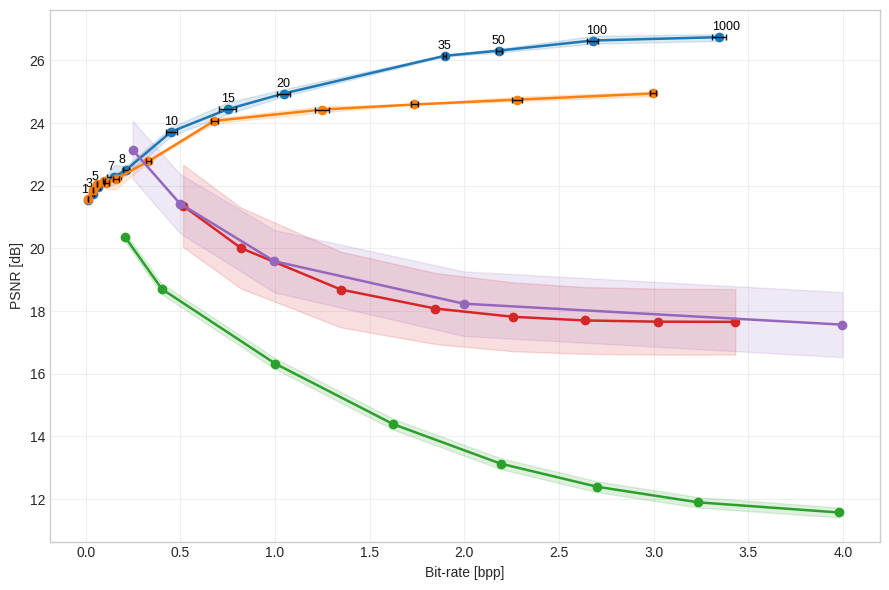

In [10]:
# ── PSNR ──────────────────────────────────────────────────────────
rd_stats_psnr, resolved_psnr = aggregate_rd_statistics(
    filtered_runs_df,
    rate_metric='rate',
    quality_metric='psnr_amp',
    group_columns=RD_PLOT_CFG['group_columns'],
)

baseline_psnr = pd.DataFrame()
if not baseline_rd_stats_df.empty:
    baseline_psnr = adapt_baseline_quality(baseline_rd_stats_df, resolved_psnr['quality_metric'])
    baseline_psnr = filter_baseline_by_bpp(baseline_psnr, RD_PLOT_CFG['max_codec_bpp'])

combined_psnr = (
    pd.concat([rd_stats_psnr, baseline_psnr], ignore_index=True, sort=False)
    if not baseline_psnr.empty
    else rd_stats_psnr
)

fig, _ = plot_rd_curve(
    combined_psnr,
    resolved_rate_metric=resolved_psnr['rate_metric'],
    resolved_quality_metric=resolved_psnr['quality_metric'],
    show_rate_error_bars=RD_PLOT_CFG['show_rate_error_bars'],
    show_quality_band=RD_PLOT_CFG['show_quality_band'],
    annotate_lambda=RD_PLOT_CFG['annotate_lambda'],
    title=RD_PLOT_CFG['title'],
    show_rate_error_bars_for_codecs=RD_PLOT_CFG.get('show_rate_error_bars_for_codecs'),
    show_legend=False,
)
plt.show()

for ext in (["svg"]):
    out = Path("RD-curves_PSNR").with_suffix(f".{ext}")
    fig.savefig(out, bbox_inches="tight", dpi=150)
    print(f"Saved {out}")


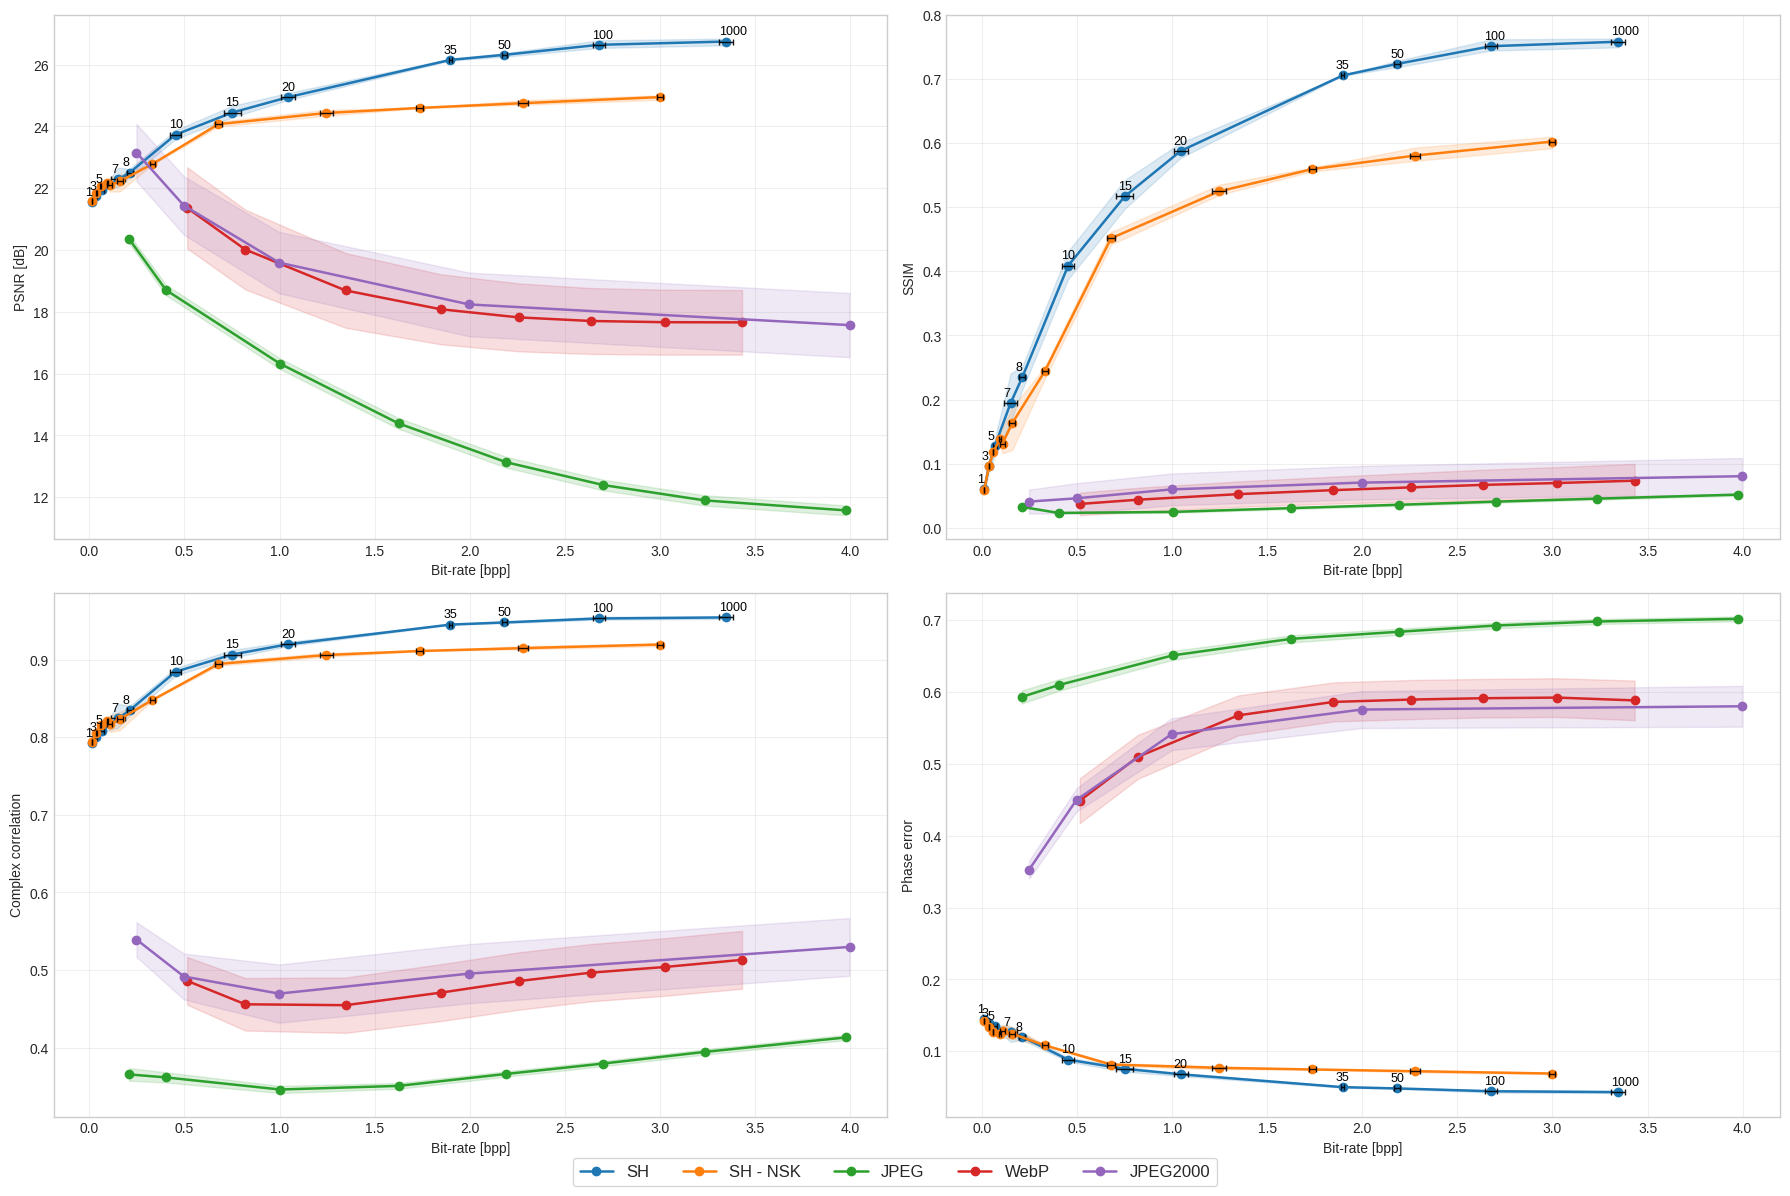

Saved RD-curves_diff_metrics.pdf
Saved RD-curves_diff_metrics.svg


In [11]:
# ── All-metrics overview (2 x N grid) ───────────────────────────────────────
# Metrics are attempted in order; any metric missing from the test results is
# skipped silently so the cell still works during early experiments.
OVERVIEW_METRICS = ['psnr_amp', 'ssim_amp', 'complex_corr', 'phase_err']

# When True, per-subplot legends are suppressed and a single shared legend is
# drawn below all subplots on one horizontal line.
OVERVIEW_SHARED_LEGEND = True

metrics_available = []
for _metric in OVERVIEW_METRICS:
    try:
        resolve_metric_key(filtered_runs_df, _metric)
        metrics_available.append(_metric)
    except KeyError:
        print(f'Metric {_metric!r} not available in test results, skipping.')

n = len(metrics_available)
n_cols = 2
n_rows = (n + 1) // 2
fig_ov, axes_ov = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), squeeze=False)

for plot_idx, metric in enumerate(metrics_available):
    row_idx, col_idx = divmod(plot_idx, n_cols)
    ax = axes_ov[row_idx, col_idx]
    try:
        stats_m, resolved_m = aggregate_rd_statistics(
            filtered_runs_df,
            rate_metric='rate',
            quality_metric=metric,
            group_columns=RD_PLOT_CFG['group_columns'],
        )
        baseline_m = pd.DataFrame()
        if not baseline_rd_stats_df.empty:
            baseline_m = adapt_baseline_quality(baseline_rd_stats_df, resolved_m['quality_metric'])
            baseline_m = filter_baseline_by_bpp(baseline_m, RD_PLOT_CFG['max_codec_bpp'])
        combined_m = (
            pd.concat([stats_m, baseline_m], ignore_index=True, sort=False)
            if not baseline_m.empty
            else stats_m
        )
        plot_rd_curve(
            combined_m,
            resolved_rate_metric=resolved_m['rate_metric'],
            resolved_quality_metric=resolved_m['quality_metric'],
            show_quality_band=True,
            show_rate_error_bars=RD_PLOT_CFG['show_rate_error_bars'],
            show_rate_error_bars_for_codecs=RD_PLOT_CFG.get('show_rate_error_bars_for_codecs'),
            annotate_lambda=True,
            title=None,
            show_legend=not OVERVIEW_SHARED_LEGEND,
            ax=ax,
        )
    except (KeyError, ValueError) as exc:
        ax.text(0.5, 0.5, str(exc), transform=ax.transAxes,
                ha='center', va='center', fontsize=8, wrap=True)
        ax.set_title(metric)

# Hide any unused axes in the last row
for plot_idx in range(n, n_rows * n_cols):
    row_idx, col_idx = divmod(plot_idx, n_cols)
    axes_ov[row_idx, col_idx].set_visible(False)

# Shared legend: collect handles from all axes, deduplicate by label, draw once.
if OVERVIEW_SHARED_LEGEND:
    seen_labels: dict[str, Any] = {}
    for ax_row in axes_ov:
        for ax in ax_row:
            for handle, label in zip(*ax.get_legend_handles_labels()):
                if label not in seen_labels:
                    seen_labels[label] = handle
    if seen_labels:
        fig_ov.legend(
            list(seen_labels.values()),
            list(seen_labels.keys()),
            loc='lower center',
            ncol=len(seen_labels),
            fontsize=12,
            frameon=True,
            bbox_to_anchor=(0.5, 0.0),
        )
        plt.tight_layout(rect=[0, 0.02, 1, 1])
    else:
        plt.tight_layout()
else:
    plt.tight_layout()

plt.show()

# save as pdf 150 dpi
for ext in (["pdf", "svg"]):
    out = Path("RD-curves_diff_metrics").with_suffix(f".{ext}")
    fig_ov.savefig(out, bbox_inches="tight", dpi=150)
    print(f"Saved {out}")


Saved RD-curve_psnr_amp.svg


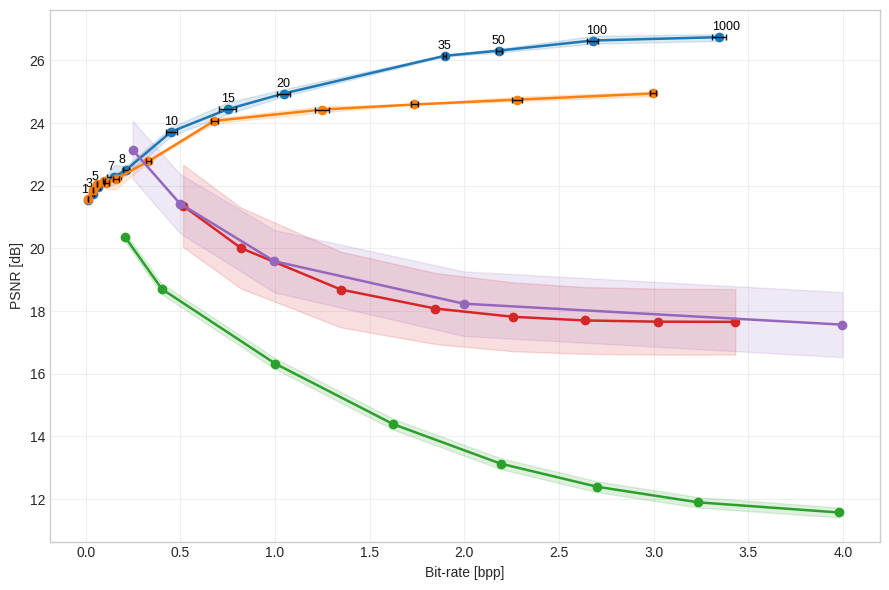

Saved RD-curve_ssim_amp.svg


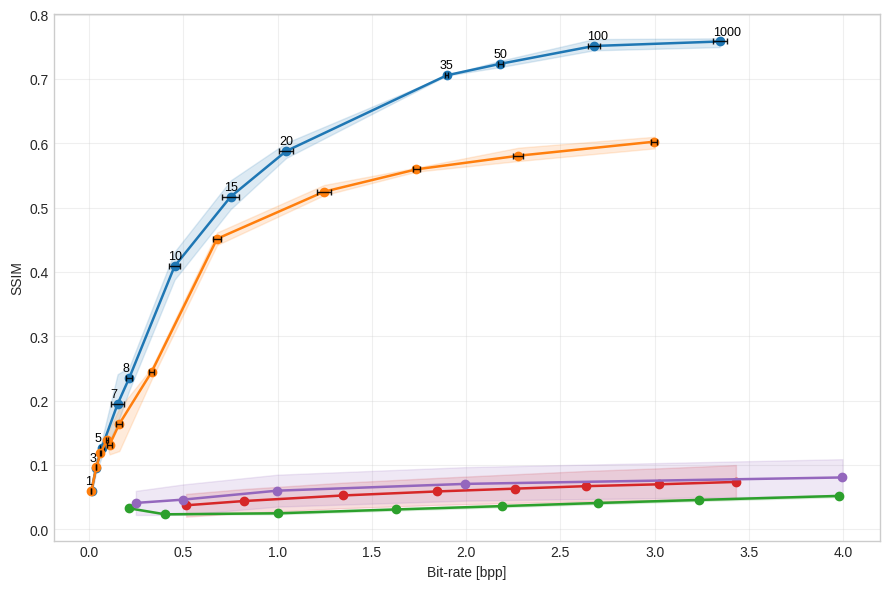

Saved RD-curve_complex_corr.svg


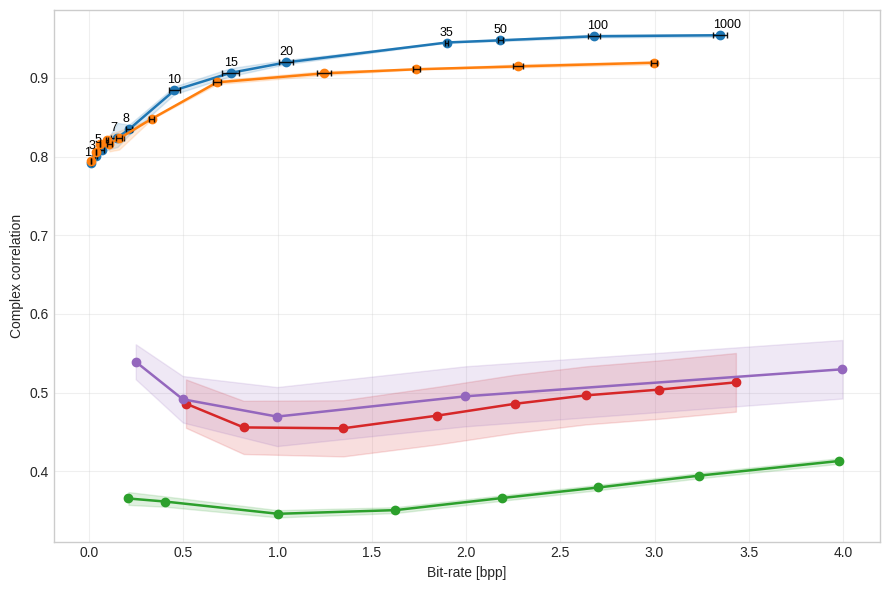

Saved RD-curve_phase_err.svg


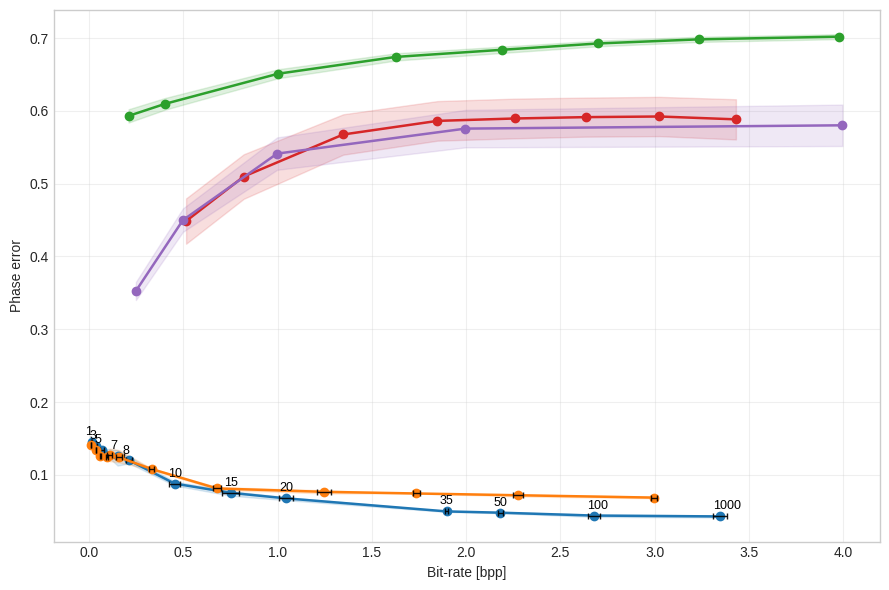

In [12]:
# ── Individual SVG per metric (no legend, for manual assembly) ───────────────
INDIVIDUAL_METRIC_OUTPUT_DIR = Path('.')  # change to a subdirectory if preferred

for metric in metrics_available:
    stats_m, resolved_m = aggregate_rd_statistics(
        filtered_runs_df,
        rate_metric='rate',
        quality_metric=metric,
        group_columns=RD_PLOT_CFG['group_columns'],
    )
    baseline_m = pd.DataFrame()
    if not baseline_rd_stats_df.empty:
        baseline_m = adapt_baseline_quality(baseline_rd_stats_df, resolved_m['quality_metric'])
        baseline_m = filter_baseline_by_bpp(baseline_m, RD_PLOT_CFG['max_codec_bpp'])
    combined_m = (
        pd.concat([stats_m, baseline_m], ignore_index=True, sort=False)
        if not baseline_m.empty
        else stats_m
    )

    fig_m, _ = plot_rd_curve(
        combined_m,
        resolved_rate_metric=resolved_m['rate_metric'],
        resolved_quality_metric=resolved_m['quality_metric'],
        show_quality_band=RD_PLOT_CFG['show_quality_band'],
        show_rate_error_bars=RD_PLOT_CFG['show_rate_error_bars'],
        show_rate_error_bars_for_codecs=RD_PLOT_CFG.get('show_rate_error_bars_for_codecs'),
        annotate_lambda=RD_PLOT_CFG['annotate_lambda'],
        title=None,
        show_legend=False,
    )

    out = INDIVIDUAL_METRIC_OUTPUT_DIR / f'RD-curve_{metric}.svg'
    fig_m.savefig(out, bbox_inches='tight')
    print(f'Saved {out}')
    plt.show()
    plt.close(fig_m)
